In [1]:
import os, warnings, sys
import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm
import bct
import torch

import neurogym as ngym
from src.neural_network import RNN, run_testing
from src.utils import get_weight_masks_schaefer, get_file_str, get_my_colors
from src.plotting import plot_activity, plot_activity_variance

# import plotting libraries
import matplotlib.pyplot as plt
from nilearn import datasets
from nctpy.plotting import surface_plot
import seaborn as sns
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
sns.set_style("white")

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# directories
if sys.platform == 'linux':
    projdir = '/home/lindenmp/research_projects/neuro_rnn'
    modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
    schaefer_dir = '/home/lindenmp/research_projects/connectome_loader/data/schaefer_parc'
elif sys.platform == 'darwin':
    projdir = '/Users/lindenmp/Google-Drive-Rutgers/work/research_projects/neuro_rnn'
    modeldir = '/Users/lindenmp/research_projects/neuro_rnn/results/pytorch/model'
datadir = os.path.join(projdir, 'data')
outdir = os.path.join(projdir, 'results/figs')

if os.path.exists(outdir) is False:
    os.mkdir(outdir)

In [3]:
# data parameters
task = 'PerceptualDecisionMaking-v0'
dt = 100
batch_size = 32
decision = 400
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
print(seq_len)
seq_len_multi = 5
seq_len = seq_len * seq_len_multi
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 100
n_runs = 100
n_epochs = 25000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.002
mask_weights = True

25
125


In [4]:
if task == 'ContextDecisionMaking-v0':
    timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
else:
    timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

# weight masks
if mask_weights:
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    centroids = centroids[:hidden_size]
    roi_names = list(centroids['ROI Name'])
    input_system = 'Vis'
    output_system = 'Default'
    # output_system = 'Cont'
    masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': n_runs, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs,
    'n_io': n_io
}

In [5]:
# setup weight masks
if mask_weights:
    input_weight_mask = np.zeros((hidden_size,))
    output_weight_mask = np.zeros((hidden_size,))
else:
    input_weight_mask = None
    output_weight_mask = None

In [6]:
# setup dataset
dataset = ngym.Dataset(config['task'], env_kwargs=env_kwargs, batch_size=config['batch_size'], seq_len=config['seq_len'])
input_size = dataset.env.observation_space.shape[0]
num_classes = dataset.env.action_space.n
print(input_size, num_classes)

3 3


# RNN dynamics

In [7]:
# # sa axis
# n_parcels = 200
# sa_axis = np.load(os.path.join(datadir, 'schaefer{0}_sa-axis.npy'.format(n_parcels)))
# sa_axis = sa_axis[:hidden_size]
# sa_axis = sp.stats.rankdata(sa_axis)

In [8]:
color_palette = sns.color_palette("Set2")
kernel_types = ['sa_axis', 'euclidean', None]
kernel_labels = ['bioRNNs', 'physRNNs', 'mRNNs']
# kernel_types = ['sa_axis', ]
# kernel_labels = ['bioRNN', ]
# kernel_types = [None, ]
# kernel_labels = ['RNN', ]
n_kernels = len(kernel_types)

In [9]:
# number of trials for lesion analysis
n_trials = 200

In [10]:
config['kernel_type'] = kernel_types[0]
file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis


In [11]:
# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(device)

# load a model to get epochs
checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
run = 0
epoch_list = []
N = 50
for idx in range(0, len(list(checkpoint[run].keys())), N):
    epoch_list.append(list(checkpoint[run].keys())[idx])
# epoch_list = epoch_list[1:76]
epoch_list = epoch_list[:5]
# del checkpoint

n_logged_epochs = len(epoch_list)
print(n_logged_epochs)
print(epoch_list)

cpu
5
[0, 4999, 9999, 14999, 19999]


In [12]:
def compute_task_variance(hidden_activity, mask=None):
    if mask is not None:
        hidden_activity = hidden_activity[:, :, mask]
    [n_trials, n_timepoints, n_nodes] = hidden_activity.shape

    hidden_activity_task_var = hidden_activity.var(axis=0)
    hidden_activity_temp_var = hidden_activity.var(axis=1)
    hidden_activity_spat_var = hidden_activity.var(axis=2)
    hidden_activity_mean = hidden_activity.mean(axis=0)

    outputs = dict()
    outputs['hidden_activity_task_var'] = hidden_activity_task_var
    outputs['hidden_activity_temp_var'] = hidden_activity_temp_var
    outputs['hidden_activity_spat_var'] = hidden_activity_spat_var
    outputs['hidden_activity_mean'] = hidden_activity_mean

    return outputs

In [13]:
hidden_activity_task_var = np.zeros((n_kernels, n_runs, n_logged_epochs))
hidden_activity_temp_var = np.zeros((n_kernels, n_runs, n_logged_epochs))
hidden_activity_spat_var = np.zeros((n_kernels, n_runs, n_logged_epochs))
hidden_activity_mean = np.zeros((n_kernels, n_runs, n_logged_epochs))

for j, kernel_type in enumerate(kernel_types):
    config['kernel_type'] = kernel_type
    file_str = get_file_str(config)
    print(file_str)

    # load model checkpoint
    checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)

    # setup kernel
    if kernel_type is None:
        regularization_kernel = None
    else:
        regularization_kernel = np.zeros((hidden_size, hidden_size))

    # setup model
    model = RNN(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes,
    type=rnn_model, regularization_kernel=regularization_kernel,
    input_weight_mask=input_weight_mask, output_weight_mask=output_weight_mask).to(device)
    model.eval()

    # compute accuracy and lesioned accuracy
    for run in tqdm(np.arange(n_runs)):
        for e, epoch in enumerate(epoch_list):
            model.load_state_dict(checkpoint[run][epoch])
            accuracy, inputs, labels, hidden_activity, output_activity, info = run_testing(dataset=dataset, model=model, n_trials=n_trials, verbose=False)

            task_variance = compute_task_variance(hidden_activity=hidden_activity, mask=masks['bystanders'])
            hidden_activity_task_var[j, run, e] = task_variance['hidden_activity_task_var'].mean()
            hidden_activity_temp_var[j, run, e] = task_variance['hidden_activity_temp_var'].mean()
            hidden_activity_spat_var[j, run, e] = task_variance['hidden_activity_spat_var'].mean()
            hidden_activity_mean[j, run, e] = task_variance['hidden_activity_mean'].mean()
            # task_variance_denom = compute_task_variance(hidden_activity=hidden_activity, mask=~masks['bystanders'])
            # hidden_activity_var[j, run, e] = task_variance['hidden_activity_var'].mean() / task_variance_denom['hidden_activity_var'].mean()
            # hidden_activity_std[j, run, e] = task_variance['hidden_activity_std'].mean() / task_variance_denom['hidden_activity_std'].mean()
            # hidden_activity_mean[j, run, e] = task_variance['hidden_activity_mean'].mean() / task_variance_denom['hidden_activity_mean'].mean()
    del checkpoint

task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis


100%|██████████| 100/100 [01:07<00:00,  1.47it/s]


task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-euclidean


100%|██████████| 100/100 [01:09<00:00,  1.45it/s]


task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-None


100%|██████████| 100/100 [01:09<00:00,  1.45it/s]


In [14]:
def categorical_kde_plot(df, variable, category, category_order=None, horizontal=False, rug=True, color_palette=None):
    """Draw a categorical KDE plot

    Parameters
    ----------
    df: pd.DataFrame
        The data to plot
    variable: str
        The column in the `df` to plot (continuous variable)
    category: str
        The column in the `df` to use for grouping (categorical variable)
    horizontal: bool
        If True, draw density plots horizontally. Otherwise, draw them
        vertically.
    rug: bool
        If True, add also a sns.rugplot.
    figsize: tuple or None
        If None, use default figsize of (7, 1*len(categories))
        If tuple, use that figsize. Given to plt.subplots as an argument.
    """
    if category_order is None:
        categories = list(df[category].unique())
    else:
        categories = category_order[:]

    figsize = (2.25, 0.2 * len(categories))

    fig, axes = plt.subplots(
        nrows=len(categories) if horizontal else 1,
        ncols=1 if horizontal else len(categories),
        figsize=figsize[::-1] if not horizontal else figsize,
        sharex=horizontal,
        sharey=not horizontal,
    )

    for i, (cat, ax) in enumerate(zip(categories, axes)):
        plot_data = df[df[category] == cat]
        sns.kdeplot(data=plot_data, ax=ax,
                    x=variable if horizontal else None,
                    y=None if horizontal else variable,
                    color=color_palette[i] if color_palette is not None else "lightslategray",
                    bw_adjust=1, clip_on=False, fill=True, alpha=1, linewidth=1
                    )
        ax.axvline(x=plot_data[variable].mean(), ymax=0.5, color='lightslategray')

        if rug:
            sns.rugplot(data=df[df[category] == cat],
                        x=variable if horizontal else None, y=None if horizontal else variable,
                        ax=ax, color="white", height=0.15, linewidth=0.5
                        )

        keep_variable_axis = (i == len(fig.axes) - 1) if horizontal else (i == 0)
        _format_axis(ax, cat, horizontal, keep_variable_axis=keep_variable_axis)

    plt.tight_layout()
    plt.show()

    return fig

def _format_axis(ax, category, horizontal=False, keep_variable_axis=True):

    # Remove the axis lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', which='major', pad=0)

    if horizontal:
        ax.set_ylabel(None)
        lim = ax.get_ylim()
        ax.set_yticks([(lim[0] + lim[1]) / 2])
        ax.set_yticklabels([category])
        if not keep_variable_axis:
            ax.get_xaxis().set_visible(False)
            ax.spines["bottom"].set_visible(False)
    else:
        ax.set_xlabel(None)
        lim = ax.get_xlim()
        ax.set_xticks([(lim[0] + lim[1]) / 2])
        ax.set_xticklabels([category])
        if not keep_variable_axis:
            ax.get_yaxis().set_visible(False)
            ax.spines["left"].set_visible(False)

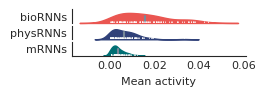

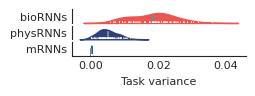

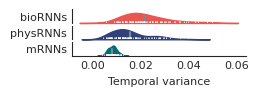

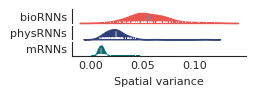

In [15]:
color_palette = get_my_colors(cat_trio=True, as_list=True)

data_to_plot = [hidden_activity_mean, hidden_activity_task_var, hidden_activity_temp_var, hidden_activity_spat_var]
data_labels = ['Mean activity', 'Task variance', 'Temporal variance', 'Spatial variance']

for plot_data, label in zip(data_to_plot, data_labels):
    if label == 'Mean activity':
        df = pd.DataFrame(data=np.abs(plot_data[:, :, -1].T), columns=kernel_labels)
    else:
        df = pd.DataFrame(data=plot_data[:, :, -1].T, columns=kernel_labels)
    df = pd.melt(df)
    #     df = df.abs
    df.columns = ['RNN', label]
    fig = categorical_kde_plot(df, variable=label, category="RNN", horizontal=True, color_palette=color_palette)
    fig.savefig(os.path.join(outdir, '{0}_internal_node_{1}.svg'.format(task, label.replace(" ", "_"))), dpi=600, bbox_inches='tight', pad_inches=0.01)